<a href="https://colab.research.google.com/github/Anashameed2303/Hyper-Spectral-Image-Classification/blob/main/Hyperspectral_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Run this cell FIRST to upload your files
from google.colab import files

print("Please upload Indian_pines_corrected.mat")
uploaded = files.upload()

print("\nPlease upload Indian_pines_gt.mat")
uploaded = files.upload()

print("\n✓ Files uploaded successfully!")

Please upload Indian_pines_corrected.mat


Saving Indian_pines_corrected.mat to Indian_pines_corrected.mat

Please upload Indian_pines_gt.mat


Saving Indian_pines_gt.mat to Indian_pines_gt.mat

✓ Files uploaded successfully!


In [ ]:
# ============================================
# PART 1: IMPORT ALL REQUIRED LIBRARIES
# ============================================



# Numerical operations
import numpy as np  # For arrays and matrix operations

# Load .mat files
import scipy.io as sio  # MATLAB file reader

# Data splitting and preprocessing
from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.preprocessing import StandardScaler  # Normalize data

# Machine Learning Models
from sklearn.svm import SVC  # Support Vector Machine
from sklearn.ensemble import RandomForestClassifier  # Random Forest

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Visualization
import matplotlib.pyplot as plt  # Plotting graphs
import seaborn as sns  # Better-looking graphs

# Deep Learning (PyTorch)
import torch
import torch.nn as nn  # Neural network layers
import torch.optim as optim  # Optimizers (Adam, SGD)
from torch.utils.data import DataLoader, TensorDataset  # Data loading

# Suppress warnings (optional, makes output cleaner)
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [ ]:
# ============================================
# PART 2: LOAD THE INDIAN PINES DATASET
# ============================================

# Load the hyperspectral image (contains 200 spectral bands)
# This is the actual satellite data
hyperspectral_data = sio.loadmat('Indian_pines_corrected.mat')
print("Step 1: Loading hyperspectral image file...")
print("Keys in file:", hyperspectral_data.keys())

# Find the actual variable name in the .mat file

for key in hyperspectral_data.keys():
    if not key.startswith('__'):  # Skip metadata keys
        image = hyperspectral_data[key]
        print(f"Found data in variable: '{key}'")
        break

print(f"\nShape of hyperspectral image: {image.shape}")
print("This means: (145 rows, 145 columns, 200 spectral bands)")
print("-" * 60)

# Load the ground truth labels (what each pixel actually is)
# This is the "answer key" we use for training
ground_truth = sio.loadmat('Indian_pines_gt.mat')
print("\nStep 2: Loading ground truth labels...")
print("Keys in file:", ground_truth.keys())

for key in ground_truth.keys():
    if not key.startswith('__'):
        labels = ground_truth[key]
        print(f"Found labels in variable: '{key}'")
        break

print(f"\nShape of ground truth: {labels.shape}")
print("This means: (145 rows, 145 columns) - one label per pixel")
print(f"Unique label values: {np.unique(labels)}")
print("Note: 0 = unlabeled background, 1-16 = different land cover types")

Step 1: Loading hyperspectral image file...
Keys in file: dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_corrected'])
Found data in variable: 'indian_pines_corrected'

Shape of hyperspectral image: (145, 145, 200)
This means: (145 rows, 145 columns, 200 spectral bands)
------------------------------------------------------------

Step 2: Loading ground truth labels...
Keys in file: dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_gt'])
Found labels in variable: 'indian_pines_gt'

Shape of ground truth: (145, 145)
This means: (145 rows, 145 columns) - one label per pixel
Unique label values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Note: 0 = unlabeled background, 1-16 = different land cover types


In [ ]:
# ============================================
# PART 3: PREPROCESSING - PREPARE DATA FOR MODELS
# ============================================

print("\n" + "="*60)
print("STEP 3: DATA PREPROCESSING")
print("="*60)

# 3.1: Reshape 3D image to 2D
# Original: (145 rows, 145 cols, 200 bands)
# We convert to: (21025 pixels, 200 bands)
rows, cols, bands = image.shape
X = image.reshape(rows * cols, bands)  # Flatten spatial dimensions
y = labels.reshape(rows * cols)        # Flatten labels

print(f"3.1 Flattening the image:")
print(f"   Original shape: {image.shape}")
print(f"   New shape (pixels × bands): {X.shape}")
print(f"   Labels shape: {y.shape}")

# 3.2: Remove unlabeled pixels (where label == 0)
# We only want to classify actual land cover, not background
mask = y != 0
X = X[mask]
y = y[mask]

print(f"\n3.2 Removing background pixels (label = 0):")
print(f"   Before removal: 21025 total pixels")
print(f"   After removal: {X.shape[0]} labeled pixels")
print(f"   Unique classes: {np.unique(y)}")

# 3.3: Normalize the data (Standardization)
# Makes each band have mean=0 and standard deviation=1
# This is important because different bands have different value ranges
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

print(f"\n3.3 Normalizing the data:")
print(f"   Before normalization - min: {X.min():.2f}, max: {X.max():.2f}")
print(f"   After normalization - min: {X_normalized.min():.2f}, max: {X_normalized.max():.2f}")

# 3.4: Split into training and testing sets
# 70% for training, 30% for testing
# stratify=y ensures same class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n3.4 Splitting data:")
print(f"   Training samples: {X_train.shape[0]} ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"   Testing samples: {X_test.shape[0]} ({X_test.shape[0]/X.shape[0]*100:.1f}%)")
print(f"   Number of spectral bands (features): {X_train.shape[1]}")
print(f"   Number of classes: {len(np.unique(y))}")


STEP 3: DATA PREPROCESSING
3.1 Flattening the image:
   Original shape: (145, 145, 200)
   New shape (pixels × bands): (21025, 200)
   Labels shape: (21025,)

3.2 Removing background pixels (label = 0):
   Before removal: 21025 total pixels
   After removal: 10249 labeled pixels
   Unique classes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]

3.3 Normalizing the data:
   Before normalization - min: 985.00, max: 9604.00
   After normalization - min: -8.05, max: 7.01

3.4 Splitting data:
   Training samples: 7174 (70.0%)
   Testing samples: 3075 (30.0%)
   Number of spectral bands (features): 200
   Number of classes: 16


In [ ]:
# ============================================
# PART 4: SUPPORT VECTOR MACHINE (SVM)
# ============================================

print("\n" + "="*60)
print("STEP 4: TRAINING SVM CLASSIFIER")
print("="*60)

# Create SVM model with RBF kernel
# C = 100: Regularization parameter (higher = more complex boundary)
# gamma = 'scale': How far a single training example influences
svm_model = SVC(kernel='rbf', C=100, gamma='scale', random_state=42)

# Train the model
print("Training SVM model...")
svm_model.fit(X_train, y_train)

# Make predictions on test data
y_pred_svm = svm_model.predict(X_test)

# Calculate performance metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='weighted')
svm_recall = recall_score(y_test, y_pred_svm, average='weighted')
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

print(f"\n📊 SVM Performance:")
print(f"   Accuracy:  {svm_accuracy*100:.2f}%")
print(f"   Precision: {svm_precision*100:.2f}%")
print(f"   Recall:    {svm_recall*100:.2f}%")
print(f"   F1-Score:  {svm_f1*100:.2f}%")

print("\n📋 SVM Detailed Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Store confusion matrix for later comparison
cm_svm = confusion_matrix(y_test, y_pred_svm)


STEP 4: TRAINING SVM CLASSIFIER
Training SVM model...

📊 SVM Performance:
   Accuracy:  92.10%
   Precision: 92.06%
   Recall:    92.10%
   F1-Score:  92.06%

📋 SVM Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.71      0.80        14
           2       0.89      0.93      0.91       428
           3       0.88      0.89      0.89       249
           4       0.80      0.73      0.76        71
           5       0.97      0.97      0.97       145
           6       0.99      0.99      0.99       219
           7       0.88      0.88      0.88         8
           8       0.97      0.99      0.98       143
           9       0.86      1.00      0.92         6
          10       0.89      0.86      0.87       292
          11       0.93      0.92      0.92       737
          12       0.90      0.92      0.91       178
          13       0.98      1.00      0.99        61
          14       0.95      0.97      0.96  

In [ ]:
# ============================================
# PART 5: RANDOM FOREST CLASSIFIER
# ============================================

print("\n" + "="*60)
print("STEP 5: TRAINING RANDOM FOREST CLASSIFIER")
print("="*60)

# Create Random Forest model
# n_estimators = 100: Number of decision trees in the forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
print("Training Random Forest model...")
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print(f"\n📊 Random Forest Performance:")
print(f"   Accuracy:  {rf_accuracy*100:.2f}%")
print(f"   Precision: {rf_precision*100:.2f}%")
print(f"   Recall:    {rf_recall*100:.2f}%")
print(f"   F1-Score:  {rf_f1*100:.2f}%")

print("\n📋 Random Forest Detailed Classification Report:")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)


STEP 5: TRAINING RANDOM FOREST CLASSIFIER
Training Random Forest model...

📊 Random Forest Performance:
   Accuracy:  86.63%
   Precision: 86.71%
   Recall:    86.63%
   F1-Score:  86.34%

📋 Random Forest Detailed Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.64      0.78        14
           2       0.88      0.81      0.84       428
           3       0.88      0.69      0.77       249
           4       0.80      0.66      0.72        71
           5       0.96      0.90      0.93       145
           6       0.88      0.97      0.92       219
           7       1.00      0.88      0.93         8
           8       0.95      0.99      0.97       143
           9       1.00      0.33      0.50         6
          10       0.85      0.88      0.87       292
          11       0.82      0.93      0.87       737
          12       0.80      0.79      0.79       178
          13       0.94      0.95      0.94        61
     


STEP 6: TRAINING CNN MODEL
Data prepared for CNN:
   Training batches: 113
   Testing batches: 49
   Batch size: 64 samples

CNN Architecture:
   Input dimension: 200 spectral bands
   Output classes: 16
   Total parameters: 418,128

Starting training for 50 epochs...
----------------------------------------
Epoch [10/50], Loss: 0.4500
Epoch [20/50], Loss: 0.3157
Epoch [30/50], Loss: 0.2155
Epoch [40/50], Loss: 0.1672
Epoch [50/50], Loss: 0.1321
----------------------------------------
Training complete!

📊 CNN Performance:
   Accuracy:  91.15%
   Precision: 91.32%
   Recall:    91.15%
   F1-Score:  91.17%

📋 CNN Detailed Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.93      0.96        14
           2       0.86      0.91      0.88       428
           3       0.90      0.85      0.87       249
           4       0.84      0.87      0.86        71
           5       0.95      0.93      0.94       145
           6       0.

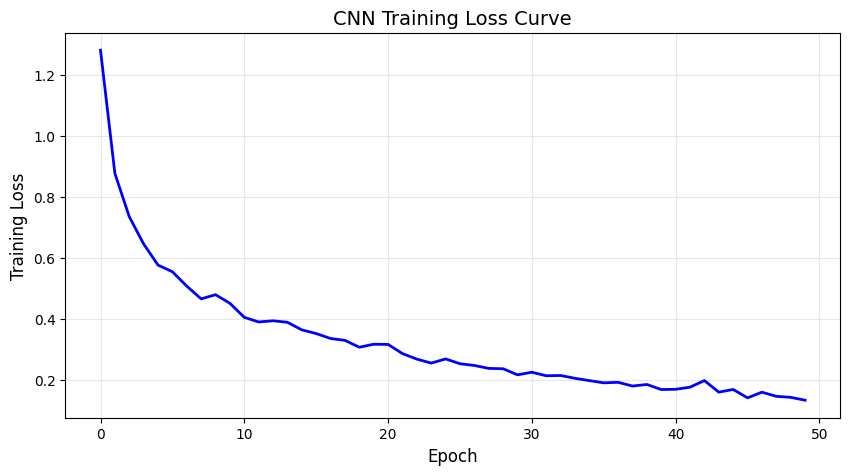

In [ ]:
# ============================================
# PART 6: CONVOLUTIONAL NEURAL NETWORK (CNN)
# ============================================

print("\n" + "="*60)
print("STEP 6: TRAINING CNN MODEL")
print("="*60)

# 6.1: Convert data to PyTorch tensors
# CNN expects class labels starting from 0, so subtract 1 (1-16 → 0-15)
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.LongTensor(y_train - 1)
y_test_tensor = torch.LongTensor(y_test - 1)

# 6.2: Create DataLoaders for batch processing
# Batch size = 64: Process 64 samples at a time
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Data prepared for CNN:")
print(f"   Training batches: {len(train_loader)}")
print(f"   Testing batches: {len(test_loader)}")
print(f"   Batch size: 64 samples")

# 6.3: Define the CNN Architecture
class Simple1DCNN(nn.Module):
    """
    A simple 1D Convolutional Neural Network for spectral data.

    Architecture:
    - Input: 200 spectral bands
    - Conv1 → Conv2 → Flatten → Dense → Output
    """
    def __init__(self, input_dim, num_classes):
        super(Simple1DCNN, self).__init__()

        # First convolutional layer: 1 channel → 32 channels
        # kernel_size=3: Looks at 3 adjacent bands at a time
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1)

        # Second convolutional layer: 32 channels → 64 channels
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Max pooling: Reduces size by half (takes maximum in each 2-element window)
        self.pool = nn.MaxPool1d(kernel_size=2)

        # Dropout: Randomly turns off 30% of neurons to prevent overfitting
        self.dropout = nn.Dropout(0.3)

        # After two pooling layers, size becomes input_dim / 4
        self.flattened_size = 64 * (input_dim // 2) // 2

        # Fully connected layers
        self.fc1 = nn.Linear(self.flattened_size, 128)  # Dense layer 1
        self.fc2 = nn.Linear(128, num_classes)          # Output layer

        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        """
        Forward pass: how data flows through the network
        """
        # Input shape: (batch_size, 200) → (batch_size, 1, 200)
        x = x.unsqueeze(1)

        # Conv1 + ReLU + Pooling
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        # Conv2 + ReLU + Pooling
        x = self.relu(self.conv2(x))
        x = self.pool(x)

        # Flatten: Convert 2D to 1D
        x = x.view(x.size(0), -1)

        # Dropout + Dense layers
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# 6.4: Initialize the model
input_dim = X_train.shape[1]   # 200 spectral bands
num_classes = len(np.unique(y))  # 16 land cover types
model = Simple1DCNN(input_dim, num_classes)

print(f"\nCNN Architecture:")
print(f"   Input dimension: {input_dim} spectral bands")
print(f"   Output classes: {num_classes}")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# 6.5: Loss function and optimizer
# CrossEntropyLoss: Standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer: Adaptive learning rate optimization
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6.6: Training loop
epochs = 50  # Number of complete passes through the data
train_losses = []  # Store loss for plotting

print(f"\nStarting training for {epochs} epochs...")
print("-" * 40)

for epoch in range(epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        # Reset gradients
        optimizer.zero_grad()

        # Forward pass: Make predictions
        outputs = model(batch_X)

        # Calculate loss (how wrong the predictions are)
        loss = criterion(outputs, batch_y)

        # Backward pass: Calculate gradients
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:2d}/{epochs}], Loss: {avg_loss:.4f}")

print("-" * 40)
print("Training complete!")

# 6.7: Evaluate the model
model.eval()  # Set to evaluation mode (disables dropout)
y_pred_cnn = []
y_true_cnn = []

with torch.no_grad():  # No gradient calculation needed for evaluation
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)  # Get class with highest probability
        y_pred_cnn.extend(predicted.numpy())
        y_true_cnn.extend(batch_y.numpy())

# Convert back to original labels (0-15 → 1-16)
y_pred_cnn = np.array(y_pred_cnn) + 1
y_true_cnn = np.array(y_true_cnn) + 1

# Calculate metrics
cnn_accuracy = accuracy_score(y_true_cnn, y_pred_cnn)
cnn_precision = precision_score(y_true_cnn, y_pred_cnn, average='weighted')
cnn_recall = recall_score(y_true_cnn, y_pred_cnn, average='weighted')
cnn_f1 = f1_score(y_true_cnn, y_pred_cnn, average='weighted')

print(f"\n📊 CNN Performance:")
print(f"   Accuracy:  {cnn_accuracy*100:.2f}%")
print(f"   Precision: {cnn_precision*100:.2f}%")
print(f"   Recall:    {cnn_recall*100:.2f}%")
print(f"   F1-Score:  {cnn_f1*100:.2f}%")

print("\n📋 CNN Detailed Classification Report:")
print(classification_report(y_true_cnn, y_pred_cnn))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

# Plot training loss curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, 'b-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('CNN Training Loss Curve', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()


STEP 7: MODEL COMPARISON
Model           Accuracy     Precision    Recall       F1-Score    
-----------------------------------------------------------------
SVM             92.10%      92.06%      92.10%      92.06%
Random Forest   86.63%      86.71%      86.63%      86.34%
CNN             91.15%      91.32%      91.15%      91.17%

🏆 Best performing model: SVM with 92.10% accuracy


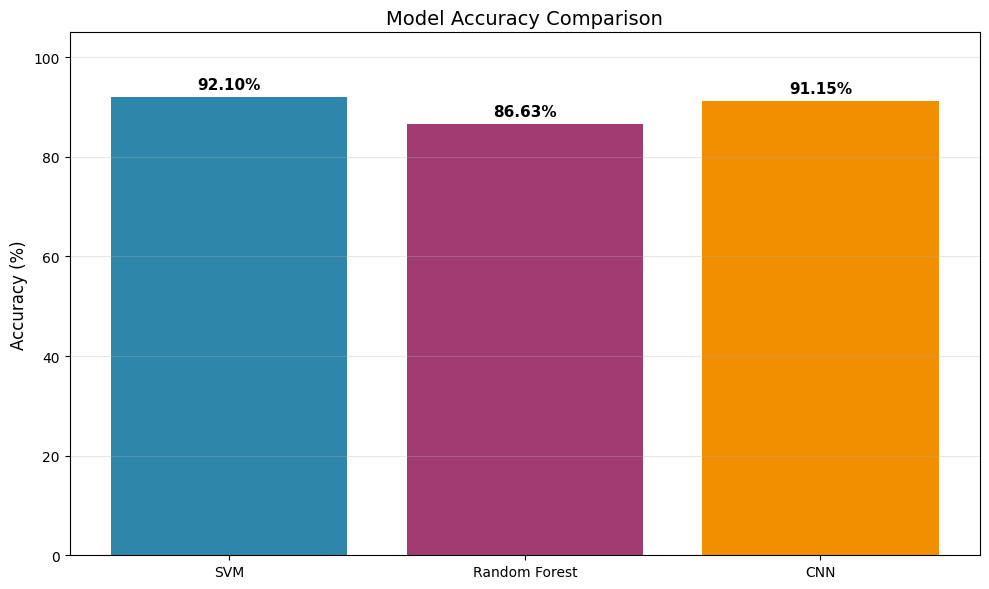

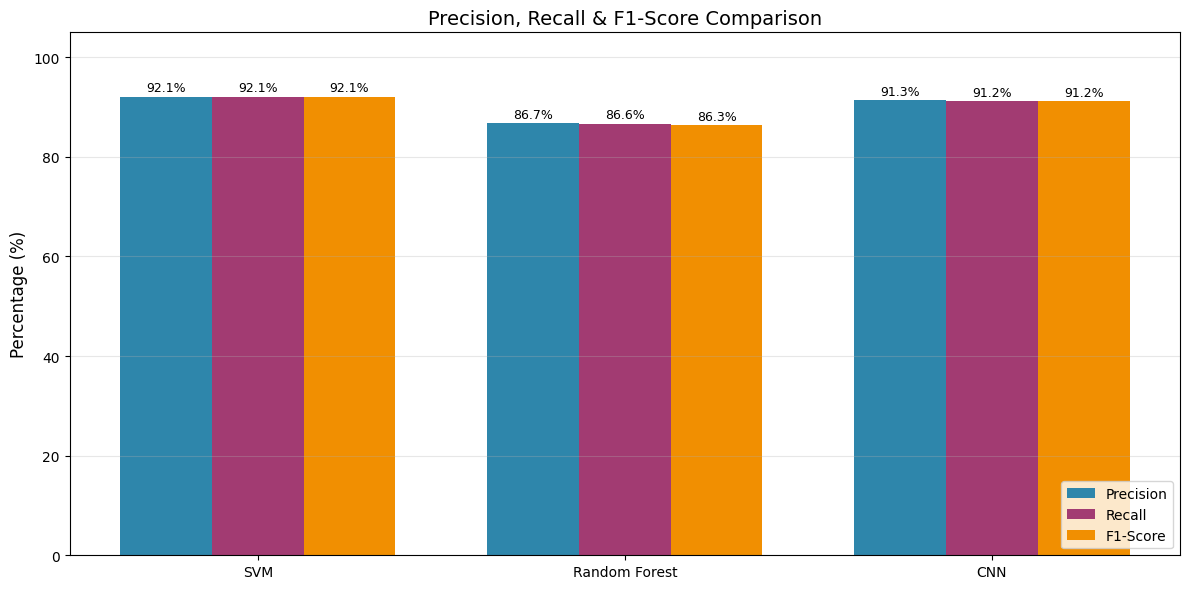

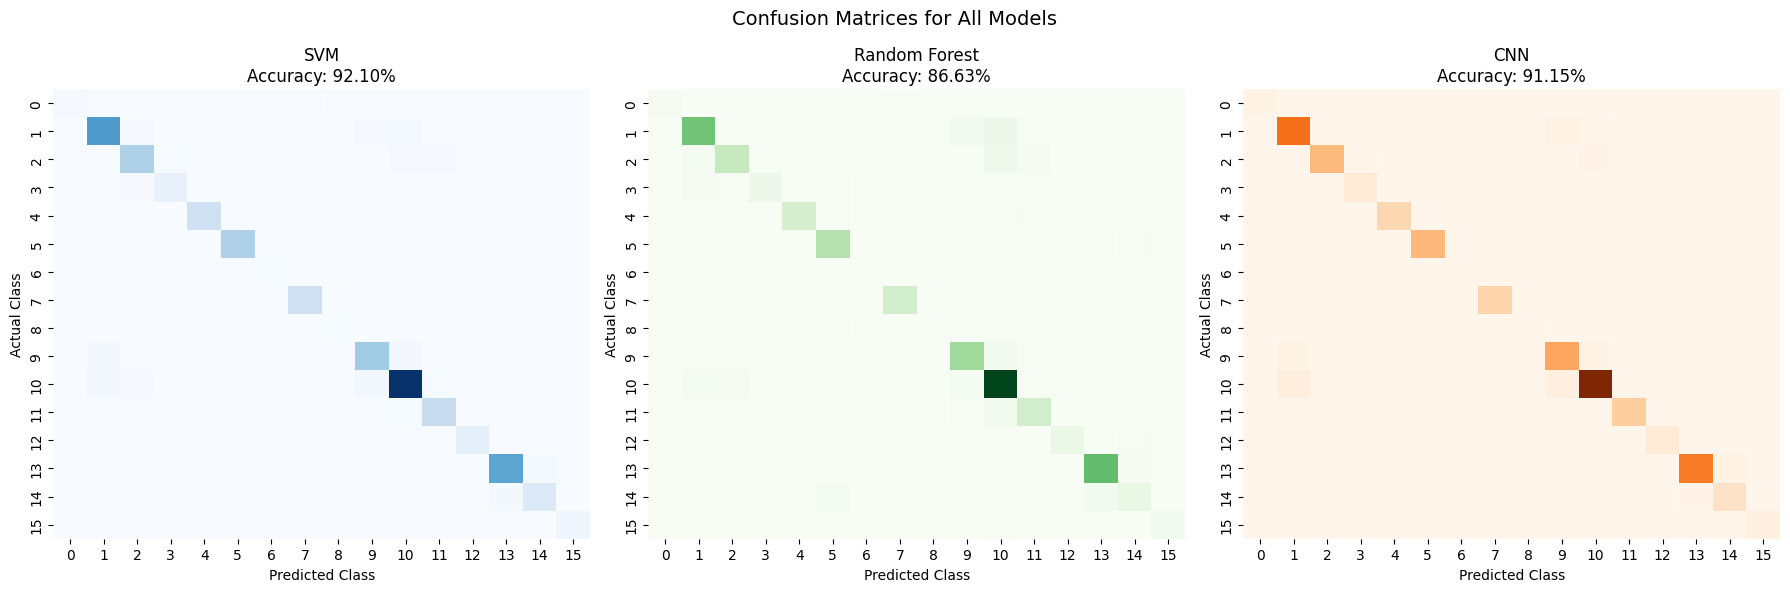

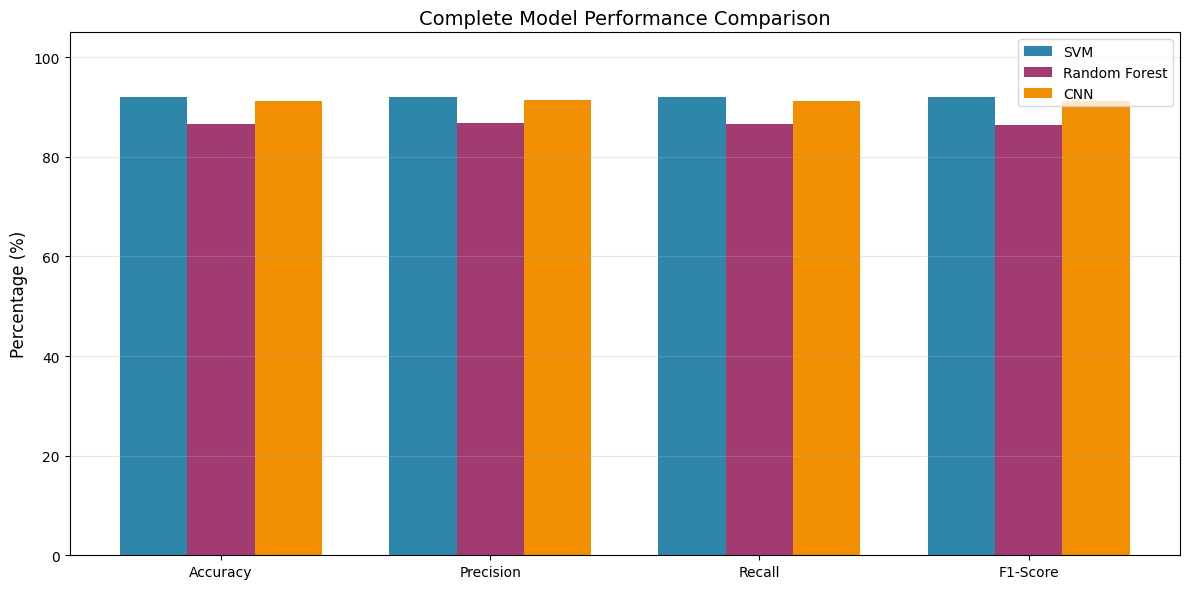

In [ ]:
# ============================================
# PART 7: COMPARE ALL MODELS
# ============================================

print("\n" + "="*60)
print("STEP 7: MODEL COMPARISON")
print("="*60)

# Create comparison table
model_names = ['SVM', 'Random Forest', 'CNN']
accuracies = [svm_accuracy*100, rf_accuracy*100, cnn_accuracy*100]
precisions = [svm_precision*100, rf_precision*100, cnn_precision*100]
recalls = [svm_recall*100, rf_recall*100, cnn_recall*100]
f1_scores = [svm_f1*100, rf_f1*100, cnn_f1*100]

# Print formatted table
print(f"{'Model':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 65)
for i, name in enumerate(model_names):
    print(f"{name:<15} {accuracies[i]:.2f}%      {precisions[i]:.2f}%      {recalls[i]:.2f}%      {f1_scores[i]:.2f}%")
print("="*65)

# Find best model
best_idx = np.argmax(accuracies)
print(f"\n🏆 Best performing model: {model_names[best_idx]} with {accuracies[best_idx]:.2f}% accuracy")

# 7.1: Accuracy Bar Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=['#2E86AB', '#A23B72', '#F18F01'])
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 7.2: Multi-metric comparison chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(model_names))
width = 0.25

bars1 = ax.bar(x - width, precisions, width, label='Precision', color='#2E86AB')
bars2 = ax.bar(x, recalls, width, label='Recall', color='#A23B72')
bars3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='#F18F01')

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Precision, Recall & F1-Score Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend(loc='lower right')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 7.3: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# SVM Confusion Matrix
sns.heatmap(cm_svm, annot=False, fmt='d', ax=axes[0], cmap='Blues', cbar=False)
axes[0].set_title(f'SVM\nAccuracy: {svm_accuracy*100:.2f}%', fontsize=12)
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('Actual Class')

# Random Forest Confusion Matrix
sns.heatmap(cm_rf, annot=False, fmt='d', ax=axes[1], cmap='Greens', cbar=False)
axes[1].set_title(f'Random Forest\nAccuracy: {rf_accuracy*100:.2f}%', fontsize=12)
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('Actual Class')

# CNN Confusion Matrix
sns.heatmap(cm_cnn, annot=False, fmt='d', ax=axes[2], cmap='Oranges', cbar=False)
axes[2].set_title(f'CNN\nAccuracy: {cnn_accuracy*100:.2f}%', fontsize=12)
axes[2].set_xlabel('Predicted Class')
axes[2].set_ylabel('Actual Class')

plt.suptitle('Confusion Matrices for All Models', fontsize=14)
plt.tight_layout()
plt.show()

# 7.4: Summary Bar Chart (All metrics together)
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
svm_scores = [svm_accuracy*100, svm_precision*100, svm_recall*100, svm_f1*100]
rf_scores = [rf_accuracy*100, rf_precision*100, rf_recall*100, rf_f1*100]
cnn_scores = [cnn_accuracy*100, cnn_precision*100, cnn_recall*100, cnn_f1*100]

x = np.arange(len(metrics))
width = 0.25

ax.bar(x - width, svm_scores, width, label='SVM', color='#2E86AB')
ax.bar(x, rf_scores, width, label='Random Forest', color='#A23B72')
ax.bar(x + width, cnn_scores, width, label='CNN', color='#F18F01')

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Complete Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# PART 8: SAVE RESULTS FOR CHAPTER 5
# ============================================

# Create a summary dictionary
results = {
    'SVM': {
        'accuracy': svm_accuracy,
        'precision': svm_precision,
        'recall': svm_recall,
        'f1_score': svm_f1
    },
    'Random Forest': {
        'accuracy': rf_accuracy,
        'precision': rf_precision,
        'recall': rf_recall,
        'f1_score': rf_f1
    },
    'CNN': {
        'accuracy': cnn_accuracy,
        'precision': cnn_precision,
        'recall': cnn_recall,
        'f1_score': cnn_f1
    }
}

# Print final summary for report
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY FOR YOUR REPORT")
print("="*60)
print("\nTable 5.1: Model Performance Comparison")
print("-" * 60)
print(f"{'Model':<15} {'Accuracy (%)':<15} {'Precision (%)':<15} {'Recall (%)':<15} {'F1-Score (%)':<15}")
print("-" * 60)
print(f"{'SVM':<15} {svm_accuracy*100:<15.2f} {svm_precision*100:<15.2f} {svm_recall*100:<15.2f} {svm_f1*100:<15.2f}")
print(f"{'Random Forest':<15} {rf_accuracy*100:<15.2f} {rf_precision*100:<15.2f} {rf_recall*100:<15.2f} {rf_f1*100:<15.2f}")
print(f"{'CNN':<15} {cnn_accuracy*100:<15.2f} {cnn_precision*100:<15.2f} {cnn_recall*100:<15.2f} {cnn_f1*100:<15.2f}")
print("-" * 60)

# Save to file
with open('classification_results.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("INDIAN PINES HYPERSPECTRAL CLASSIFICATION RESULTS\n")
    f.write("="*60 + "\n\n")

    f.write("DATASET INFORMATION\n")
    f.write("-"*40 + "\n")
    f.write(f"Total labeled pixels: {X.shape[0]}\n")
    f.write(f"Number of spectral bands: {bands}\n")
    f.write(f"Number of classes: {len(np.unique(y))}\n")
    f.write(f"Training samples: {X_train.shape[0]} (70%)\n")
    f.write(f"Testing samples: {X_test.shape[0]} (30%)\n\n")

    f.write("MODEL PERFORMANCE SUMMARY\n")
    f.write("-"*60 + "\n")
    f.write(f"{'Model':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}\n")
    f.write("-"*60 + "\n")
    f.write(f"{'SVM':<15} {svm_accuracy*100:.2f}%      {svm_precision*100:.2f}%      {svm_recall*100:.2f}%      {svm_f1*100:.2f}%\n")
    f.write(f"{'Random Forest':<15} {rf_accuracy*100:.2f}%      {rf_precision*100:.2f}%      {rf_recall*100:.2f}%      {rf_f1*100:.2f}%\n")
    f.write(f"{'CNN':<15} {cnn_accuracy*100:.2f}%      {cnn_precision*100:.2f}%      {cnn_recall*100:.2f}%      {cnn_f1*100:.2f}%\n")
    f.write("-"*60 + "\n\n")

    f.write(f"BEST PERFORMING MODEL: {model_names[best_idx]} with {accuracies[best_idx]:.2f}% accuracy\n")

print("\n✓ Results saved to 'classification_results.txt'")
print("✓ You can download this file using the Files panel on the left")
print("\n🎉 All done! You can now use these results for your report.")


FINAL RESULTS SUMMARY FOR YOUR REPORT

Table 5.1: Model Performance Comparison
------------------------------------------------------------
Model           Accuracy (%)    Precision (%)   Recall (%)      F1-Score (%)   
------------------------------------------------------------
SVM             92.10           92.06           92.10           92.06          
Random Forest   86.63           86.71           86.63           86.34          
CNN             91.15           91.32           91.15           91.17          
------------------------------------------------------------

✓ Results saved to 'classification_results.txt'
✓ You can download this file using the Files panel on the left

🎉 All done! You can now use these results for your report.


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(y_test, y_pred, model_name):
    print(f"--- {model_name} ---")

    # Classification Report
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=False, cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()